#  Анализ пользовательской активности в сервисе для чтения и прослушивания книг
Автор: Ельцова Анастасия

---
## Цели и задачи проекта

#### Цель проекта

Статистически проверить гипотезу о том, что пользователи из Санкт-Петербурга в среднем проводят больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

Для этого будет проведена односторонняя проверка гипотезы с двумя выборками:

* Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей из Санкт-Петербурга меньше или равно среднему времени пользователей из Москвы.

* Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей из Санкт-Петербурга статистически значимо больше среднего времени пользователей из Москвы.

По результатам анализа будет подготовлена аналитическая записка с выводами.

#### Задачи проекта

* загрузка данных пользователей из Москвы и Саннкт-Петербурга с суммой часов их активности
* предобработка данных
* сравнение размера групп и их статистики
* проверка гипотезы

## Описание данных

Для анализа поступила таблица `knigi_data.csv`, которая содержит следующие столбцы:
* `Unnamed: 0` - дублирует индексы
* `city` - город
* `puid` - идентификатор пользователя
* `hours` - длительность чтения или прослушивания в часах

## Содержимое проекта

1. Загрузка, знакомство и предобработка данных
2. Проверка гипотезы
3. Аналитическая записка

---

## 1. Загрузка, знакомство и предобработка данных

Загрузим данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `knigi_data.csv`.

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Считаем и сохраним датафрейм с данными пользователей из Москвы и Санкт-Петербурга
try:
    df = pd.read_csv("https://code._____.csv")
except:
    df = pd.read_csv("https://code._____.csv")
display(df.head())

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


---
Столбец `Unnamed: 0`, дублирует индекс данных и не несет смысловой нагрузки, поэтому сделаем его индексом.

---

In [3]:
# Установим столбец как индекс
df = df.set_index("Unnamed: 0")
df.index.name = None
df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [4]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB


---
В результате первичного анализа данных были получены следующие выводы:

Датасет состоит из 8 784 наблюдений и 4 столбцов.

Качество данных:
* Пропущенные значения в данных отсутствуют.
* Типы данных во всех столбцах определены корректно.
* Проверка на явные аномалии и несоответствия формата не выявила проблем.
* Обнаружен технический столбец `Unnamed: 0`, который дублирует индекс данных и не несет смысловой нагрузки - сделали его индексом.

---

In [5]:
# Проверяем датасет на явные дубликаты
duplicate_count = df.duplicated().sum()

if duplicate_count == 0:
    print("Явных дубликатов не обнаружено")
else:
    print(f"Обнаружены явные дубликаты: {duplicate_count} шт.")

Явных дубликатов не обнаружено


In [6]:
# Проверяем наличие дубликатов в идентификаторах пользователя
duplicate_count = df["puid"].duplicated().sum()
unique_count = df["puid"].nunique()
total_count = df["puid"].count()

print(f"Всего идентификаторов: {total_count}")
print(f"Уникальных идентификаторов: {unique_count}")
print(f"Дубликатов: {duplicate_count}")

if duplicate_count > 0:
    print(f"Процент дубликатов: {duplicate_count/total_count*100:.2f}%")

Всего идентификаторов: 8784
Уникальных идентификаторов: 8540
Дубликатов: 244
Процент дубликатов: 2.78%


In [7]:
# Удаляем дубликаты
df = df.drop_duplicates(subset=["puid"]).reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8540 entries, 0 to 8539
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8540 non-null   object 
 1   puid    8540 non-null   int64  
 2   hours   8540 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 200.3+ KB


---
Дубликаты в идентификаторах пользователей успешно удалены.

После предобработки данных, сравним размеры групп и их статистики.

---

In [8]:
# Рассчитаем количество уникальных пользователей в каждой группе
group_counts = df.groupby("city", as_index=False)["puid"].nunique()
group_counts

,city,puid
0,Москва,6234
1,Санкт-Петербург,2306


---
Количество пользователей в группе Москвы превышает количество пользователей группы Санкт-Петербурга. Проверим, не попали ли пользователи в две группы одновременно.

---

In [9]:
# подсчёт уникальных групп на каждого пользователя
df.groupby("puid", as_index=False)["city"].nunique().sort_values(
    by="city", ascending=False
)

,puid,city
0,9668,1
5689,1330414003,1
5703,1334633167,1
5702,1334227047,1
5701,1334047100,1
...,...,...
2840,503850712,1
2839,503700910,1
2838,503478720,1
2837,503230743,1


---
Аномалий нет - каждый пользователь попал только в одну группу, группы независимы.

---

In [10]:
# Посмотрим, в каком процентном соотношении находятся группы
msc_share = round(
    100 * df[df["city"] == "Москва"]["puid"].nunique() / df["puid"].nunique(), 2
)
spb_share = round(
    100 * df[df["city"] == "Санкт-Петербург"]["puid"].nunique() / df["puid"].nunique(),
    2,
)
print(
    f"Доля группы пользователей в Москве:{msc_share}%. Доля группы пользователей в Санкт-Петербурге:{spb_share}%"
)

msc_count = group_counts[group_counts["city"] == "Москва"]["puid"].values[0]
spb_count = group_counts[group_counts["city"] == "Санкт-Петербург"]["puid"].values[0]

percentage_difference = round(100 * ((msc_count - spb_count) / msc_count), 2)
print(f"Процентная разница: {percentage_difference}")

Доля группы пользователей в Москве:73.0%. Доля группы пользователей в Санкт-Петербурге:27.0%
Процентная разница: 63.01


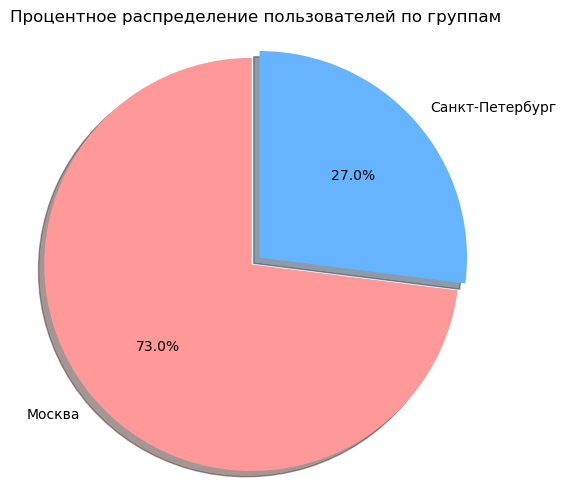

In [11]:
# Построим визуализацию, на которой будет видно различие двух групп
group_counts = df.groupby("city")["puid"].nunique()
groups = group_counts.index.tolist()
users = group_counts.values.tolist()

# Построим визуализацию
plt.figure(figsize=(6, 6))
colors = ["#ff9999", "#66b3ff"]
explode = (0.05, 0)

plt.pie(
    users,
    labels=groups,
    autopct="%1.1f%%",
    colors=colors,
    explode=explode,
    startangle=90,
    shadow=True,
)
plt.title("Процентное распределение пользователей по группам")
plt.axis("equal")
plt.show()

---
Наблюдается сильный дисбаланс групп: в Москве 73% пользователей, в Санкт-Петербурге 27%. Группа Москвы более чем в 2.5 раза больше группы Санкт-Петербурга. Разница в размерах составляет 63%. 

---

### Среднее время активности пользователей ###

Сравним статистики групп: среднее значение и медиану.

---

In [12]:
df.groupby(["city"], as_index=False).agg({"hours": ["mean", "median"]})

city      hours          
                         mean    median
0           Москва  10.881092  0.924498
1  Санкт-Петербург  11.264433  0.875355

<Figure size 1000x600 with 0 Axes>

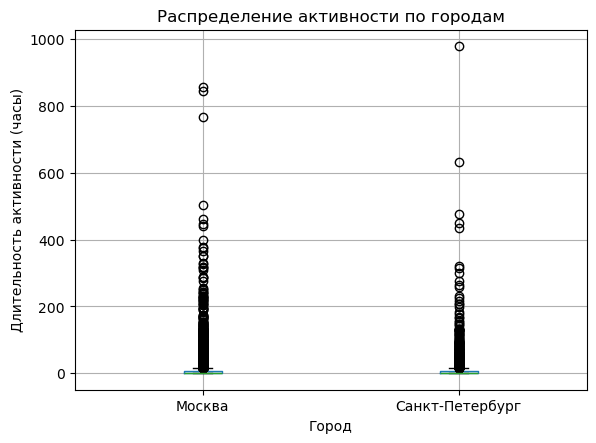

In [13]:
plt.figure(figsize=(10, 6))
df.boxplot(column="hours", by="city")
plt.title("Распределение активности по городам")
plt.suptitle("")
plt.ylabel("Длительность активности (часы)")
plt.xlabel("Город")
plt.show()

---
В данных наблюдается сильная правосторонняя ассиметрия. Медианы значительно меньше средних в обеих группах. Это указывает на наличие выбросов - небольшое количество очень активных пользователей. Распределение не нормальное (скошенное вправо). По средним значениям активнее Санкт-Петербург, по медианам активнее Москва. Наблюдаемая разница в средних, скорее всего, обусловлена выбросами, а не систематическим различием в поведении большинства пользователей. Медианы близки (0.92 vs 0.88) - большинство пользователей в обеих группах имеют схожую активность. 

Статистическая проверка покажет, являются ли эти различия значимыми. Для проверки гипотезы необходимо воспользоваться тестом Манна-Уитни, так как он не чувствителен к выбросам.

---

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга в среднем проводбольше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:
- Нулевая гипотеза H₀: Средняя активность пользователей в Санкт-Петербурге не больше или равна средней активности пользователей в Москве.
- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

---

In [14]:
# Формируем выборки
sample_1 = df.query('city == "Москва"')["hours"]
sample_2 = df.query('city == "Санкт-Петербург"')["hours"]
# Определяем альфа
alpha = 0.05
# Запускаем тест Манна-Уитни
results = st.mannwhitneyu(sample_1, sample_2, alternative="greater")

if results.pvalue > alpha:
    print(f"pvalue = {results.pvalue} > {alpha}")
    print(
        f"Нулевая гипотеза находит подтверждение. Средняя активность пользователей в Санкт-Петербурге не больше или равна средней активности пользователей в Москве."
    )
else:
    print(f"pvalue = {results.pvalue} < {alpha}")
    print(
        f"Нулевая гипотеза не находит подтверждения. Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо"
    )

pvalue = 0.3810436794993063 > 0.05
Нулевая гипотеза находит подтверждение. Средняя активность пользователей в Санкт-Петербурге не больше или равна средней активности пользователей в Москве.


---
## 3. Аналитическая записка

Для проверки гипотезы о различии пользовательской активности между географическими группами был применен непараметрический тест Манна-Уитни. Выбор обусловлен правосторонним распределением данных с наличием выбросов и отсутствием нормальности распределения. Уровень статистической значимости (α) установлен на стандартном уровне 0.05.

**Результаты тестирования**: полученное p-value: 0.38

**Статистический вывод**: Поскольку p-value значительно превышает установленный уровень значимости α = 0.05, нулевая гипотеза (H₀) не отвергается. Статистически значимых различий в активности пользователей между Москвой и Санкт-Петербургом не обнаружено. Наблюдаемые различия в средних значениях (11.26 часа в СПб против 10.88 часа в Москве) носят случайный характер и не являются статистически значимыми. Медианные значения активности практически идентичны (0.88 часа в СПб против 0.92 часа в Москве), что подтверждает схожесть поведения большинства пользователей в обоих городах.

Возможные причины результатов:
- Целевая аудитория сервиса в обоих городах может иметь аналогичные демографические и поведенческие характеристики, что нивелирует потенциальные географические различия.
- Пользовательское поведение определяется в первую очередь особенностями платформы и содержания, а не географическим расположением. Единый функционал и каталог книг формируют сходные паттерны использования сервиса независимо от города.

---